In [300]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit


Constantes

In [301]:
R = 248e3 # Ohms
C = 470e-6 # Farads
T = R * C # Time constant
V = 10 # Volts

In [302]:
def Vcap_carga(t, V, T):
    return V * (1 - np.exp(-t / T))

def Vcap_descarga(t, V, T):
    return V * np.exp(-t / T)

Carga

In [303]:
time = np.linspace(0, 5 * T, 100) # Time from 0 to 5 time constants

for t in time:
    voltage = Vcap_carga(t, V, T)
    print(f"t={t} s, Vcap={voltage:.2f} V")

t=0.0 s, Vcap=0.00 V
t=5.886868686868686 s, Vcap=0.49 V
t=11.773737373737372 s, Vcap=0.96 V
t=17.660606060606057 s, Vcap=1.41 V
t=23.547474747474745 s, Vcap=1.83 V
t=29.434343434343432 s, Vcap=2.23 V
t=35.32121212121211 s, Vcap=2.61 V
t=41.2080808080808 s, Vcap=2.98 V
t=47.09494949494949 s, Vcap=3.32 V
t=52.98181818181818 s, Vcap=3.65 V
t=58.868686868686865 s, Vcap=3.97 V
t=64.75555555555555 s, Vcap=4.26 V
t=70.64242424242423 s, Vcap=4.55 V
t=76.52929292929292 s, Vcap=4.81 V
t=82.4161616161616 s, Vcap=5.07 V
t=88.3030303030303 s, Vcap=5.31 V
t=94.18989898989898 s, Vcap=5.54 V
t=100.07676767676766 s, Vcap=5.76 V
t=105.96363636363635 s, Vcap=5.97 V
t=111.85050505050503 s, Vcap=6.17 V
t=117.73737373737373 s, Vcap=6.36 V
t=123.62424242424241 s, Vcap=6.54 V
t=129.5111111111111 s, Vcap=6.71 V
t=135.3979797979798 s, Vcap=6.87 V
t=141.28484848484845 s, Vcap=7.02 V
t=147.17171717171715 s, Vcap=7.17 V
t=153.05858585858584 s, Vcap=7.31 V
t=158.94545454545454 s, Vcap=7.44 V
t=164.8323232323232 s, 

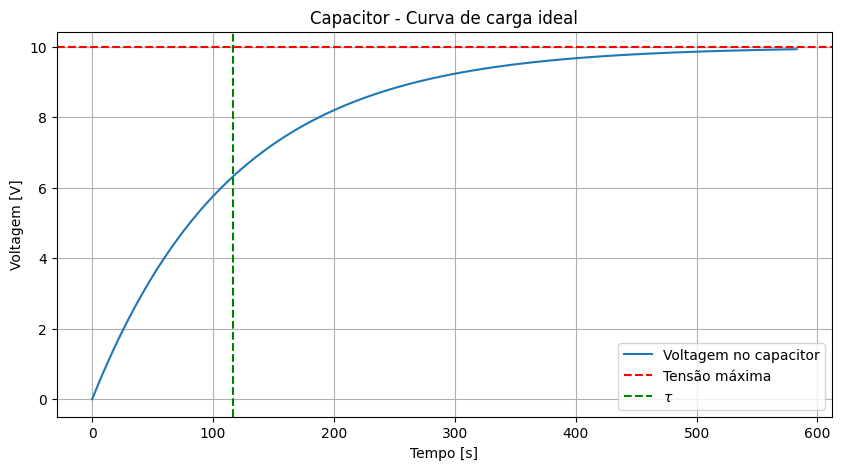

In [304]:
plt.figure(figsize=(10, 5))
plt.plot(time, Vcap_carga(time, V, T), label='Voltagem no capacitor')
plt.title('Capacitor - Curva de carga ideal') 
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axhline(V, color='red', linestyle='--', label='Tensão máxima')
plt.axvline(T, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()

In [305]:
t_exp = np.array([0, 116, 232, 348]) # Tempo em segundos
V_exp = np.array([0, 6.3, 9.2, 9.9]) # Voltagem medida em volts

# Ajuste do modelo usando curve_fit
popt, pcov = curve_fit(Vcap_carga, t_exp, V_exp, p0=[V, T])

# Parâmetros ajustados
A, B = popt
print(f"Parâmetros ajustados: V0 = {A:.4f}, T = {B:.4f}")
print(f'Equação ajustada: V(t) = {A:.4f} * (1 - exp(-t / {B:.4f}))')

# Calcular o erro padrão dos parâmetros
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: V0 = {perr[0]:.4f}, T = {perr[1]:.4f}")

# Calcular R**2
slope, intercept, r_value, p_value, std_err = linregress(Vcap_carga(t_exp,*popt),V_exp)
print(f"R² = {r_value**2:.4f}")

# Gerar valores ajustados para o gráfico
x_fit = np.linspace(min(t_exp), max(t_exp), 100)
y_fit = Vcap_carga(x_fit, A, B)

Parâmetros ajustados: V0 = 10.7094, T = 126.9722
Equação ajustada: V(t) = 10.7094 * (1 - exp(-t / 126.9722))
Erro padrão dos parâmetros: V0 = 0.3198, T = 10.5144
R² = 0.9988


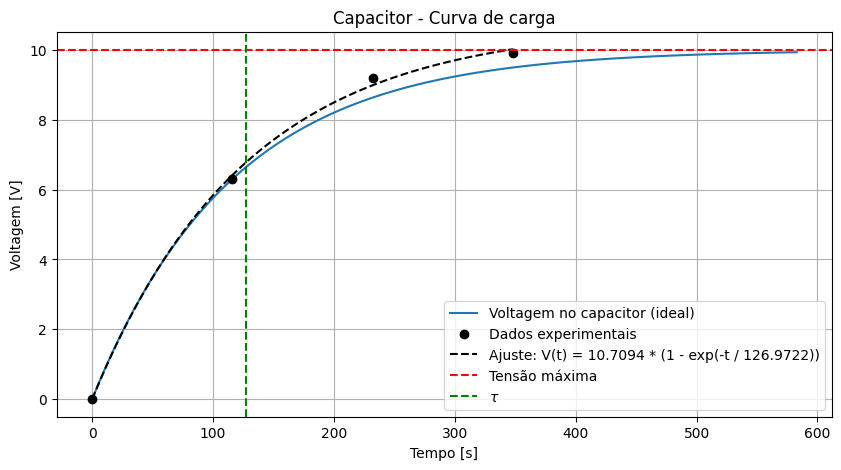

In [306]:
plt.figure(figsize=(10, 5))
plt.plot(time, Vcap_carga(time, V, T), label='Voltagem no capacitor (ideal)')
plt.plot(t_exp, V_exp, 'ko', label='Dados experimentais')
plt.plot(x_fit, y_fit, 'k--', label='Ajuste: V(t) = {:.4f} * (1 - exp(-t / {:.4f}))'.format(A, B))
plt.title('Capacitor - Curva de carga')
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axhline(V, color='red', linestyle='--', label='Tensão máxima')
plt.axvline(B, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()

---

Descarga

In [307]:
time = np.linspace(0, max(time), 100)

for t in time:
    voltage = Vcap_descarga(t, V, T)
    print(f"t={t} s, Vcap={voltage:.2f} V")

t=0.0 s, Vcap=10.00 V
t=5.886868686868686 s, Vcap=9.51 V
t=11.773737373737372 s, Vcap=9.04 V
t=17.660606060606057 s, Vcap=8.59 V
t=23.547474747474745 s, Vcap=8.17 V
t=29.434343434343432 s, Vcap=7.77 V
t=35.32121212121211 s, Vcap=7.39 V
t=41.2080808080808 s, Vcap=7.02 V
t=47.09494949494949 s, Vcap=6.68 V
t=52.98181818181818 s, Vcap=6.35 V
t=58.868686868686865 s, Vcap=6.03 V
t=64.75555555555555 s, Vcap=5.74 V
t=70.64242424242423 s, Vcap=5.45 V
t=76.52929292929292 s, Vcap=5.19 V
t=82.4161616161616 s, Vcap=4.93 V
t=88.3030303030303 s, Vcap=4.69 V
t=94.18989898989898 s, Vcap=4.46 V
t=100.07676767676766 s, Vcap=4.24 V
t=105.96363636363635 s, Vcap=4.03 V
t=111.85050505050503 s, Vcap=3.83 V
t=117.73737373737373 s, Vcap=3.64 V
t=123.62424242424241 s, Vcap=3.46 V
t=129.5111111111111 s, Vcap=3.29 V
t=135.3979797979798 s, Vcap=3.13 V
t=141.28484848484845 s, Vcap=2.98 V
t=147.17171717171715 s, Vcap=2.83 V
t=153.05858585858584 s, Vcap=2.69 V
t=158.94545454545454 s, Vcap=2.56 V
t=164.8323232323232 s,

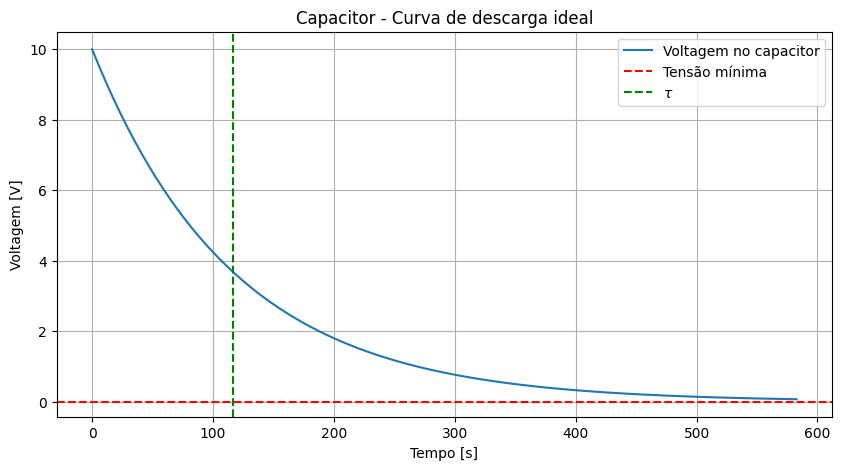

In [308]:
plt.figure(figsize=(10, 5))
plt.plot(time, Vcap_descarga(time, V, T), label='Voltagem no capacitor')
plt.title('Capacitor - Curva de descarga ideal')
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axhline(0, color='red', linestyle='--', label='Tensão mínima')
plt.axvline(T, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()

In [309]:
t_exp = np.array([0, 116, 232, 348]) # Tempo em segundos
V_exp = np.array([9.0, 6.3, 3.2, 0.5]) # Voltagem medida em volts

# Ajuste do modelo usando curve_fit
popt, pcov = curve_fit(Vcap_descarga, t_exp, V_exp, p0=[V, T])

# Parâmetros ajustados
A, B = popt
print(f"Parâmetros ajustados: V0 = {A:.4f}, T = {B:.4f}")
print(f'Equação ajustada: V(t) = {A:.4f} * (1 - exp(-t / {B:.4f}))')

# Calcular o erro padrão dos parâmetros
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: V0 = {perr[0]:.4f}, T = {perr[1]:.4f}")

# Calcular R**2
slope, intercept, r_value, p_value, std_err = linregress(Vcap_carga(t_exp,*popt),V_exp)
print(f"R² = {r_value**2:.4f}")

# Gerar valores ajustados para o gráfico
x_fit = np.linspace(min(t_exp), max(t_exp), 100)
y_fit = Vcap_descarga(x_fit, A, B)

Parâmetros ajustados: V0 = 9.3871, T = 204.7422
Equação ajustada: V(t) = 9.3871 * (1 - exp(-t / 204.7422))
Erro padrão dos parâmetros: V0 = 1.0998, T = 50.2100
R² = 0.9411


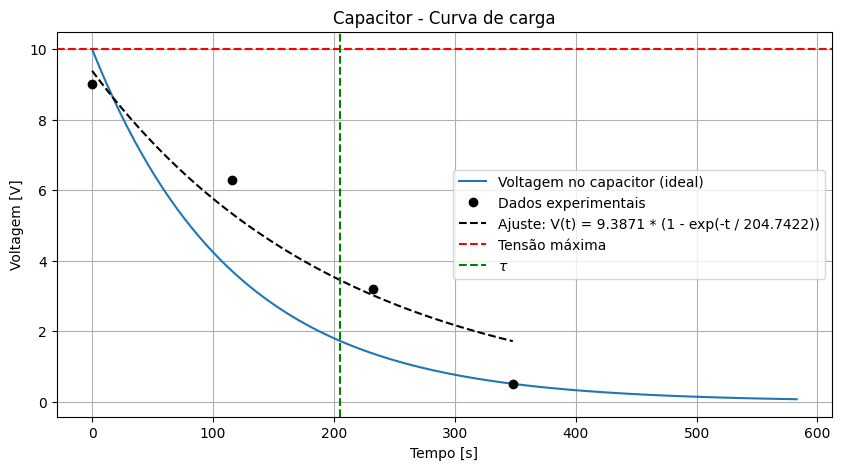

In [310]:
plt.figure(figsize=(10, 5))
plt.plot(time, Vcap_descarga(time, V, T), label='Voltagem no capacitor (ideal)')
plt.plot(t_exp, V_exp, 'ko', label='Dados experimentais')
plt.plot(x_fit, y_fit, 'k--', label='Ajuste: V(t) = {:.4f} * (1 - exp(-t / {:.4f}))'.format(A, B))
plt.title('Capacitor - Curva de carga')
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axhline(V, color='red', linestyle='--', label='Tensão máxima')
plt.axvline(B, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()